# Análisis inteligente del desempeño empresarial usando ML (Lineal, Logístico y Bayesiano)
Daniela Lizet cauich Lopez 00478483
* Regresión lineal para predecir un indicador económico (ventas).
* Regresión logística para clasificar empresas según su desempeño.
* Red bayesiana para estudiar relaciones causales y probabilísticas entre variables.

In [54]:
#Importe de librerías
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

In [2]:
# Carga de datos
df = pd.read_stata('Mexico-2023-full-data.dta')
df.columns.tolist()

['idstd',
 'id',
 'a4a',
 'a6a',
 'a2',
 'a1c',
 'competition_select',
 'tax_select',
 'vat_applicable',
 'a4b_v4',
 'a0',
 'a3a',
 'a6b',
 'a6c',
 'a7',
 'panel',
 'a1a',
 'a14d',
 'a14m',
 'a14y',
 'a14h',
 'a14min',
 'ic1',
 'a20y',
 'a20m',
 'a20d',
 'a1',
 'a7a',
 'a7b',
 'a11',
 'a7c',
 'a9',
 'b1',
 'b1x',
 'b3a',
 'b2a',
 'b2b',
 'b2c',
 'b2d',
 'b4',
 'b4a',
 'b5',
 'b6',
 'b6b',
 'b7',
 'b7a',
 'b8',
 'b8x',
 'c3',
 'c4',
 'c5',
 'c31',
 'c32',
 'c6',
 'c7',
 'c8a',
 'c8b',
 'c9a',
 'c9b',
 'c10',
 'c11',
 'c12',
 'c13',
 'c14',
 'c33',
 'c34',
 'c34b',
 'c34bx',
 'c152',
 'c162',
 'c172',
 'c35a',
 'c35b',
 'c22b',
 'c36',
 'c37',
 'c38',
 'c39',
 'c40a',
 'c40b',
 'c41a',
 'c41b',
 'c42',
 'c30a',
 'd1a1a',
 'd1a1x',
 'd1a6a',
 'd1a6b',
 'd1a6c',
 'd1a6cx',
 'd1a3',
 'd2',
 'd2x',
 'd2a1',
 'd2a1x',
 'n3',
 'n3x',
 'd3a',
 'd3b',
 'd3c',
 'd31x',
 'd32',
 'd4a',
 'd4b',
 'd33a',
 'd33b',
 'd34',
 'd35',
 'd36a',
 'd36b',
 'd37',
 'd8',
 'd12a',
 'd12b',
 'd13',
 'd38x',
 'd

In [4]:
# Se seleccionan varables necesarias para el modelo (sales, # of employees, training, financing, exporter, competition level)
cols = ['d2', 'l1', 'h1', 'k3bc', 'd3a', 'd3b', 'd3c', 'e2b']
df = df[cols].copy()
df.head()

,d2,l1,h1,k3bc,d3a,d3b,d3c,e2b
0,30700000,53,No,10,100,0,0,2
1,29000000,22,No,10,100,0,0,Don't know (spontaneous)
2,43000000,107,No,5,100,0,0,Don't know (spontaneous)
3,135000000,270,No,15,100,0,0,Too many to count
4,6000000,15,No,10,100,0,0,Too many to count


## 1. Construcción de variables

In [38]:
#Justificación: en la encuesta, los valores -9 y -4 representan No sabe / No responde, por lo que se tratan como valores faltantes reales.
df.replace([-9, -4], np.nan, inplace=True)

df_clean = pd.DataFrame()
df_clean['sales'] = pd.to_numeric(df['d2'], errors='coerce') #ventas convertidas de categorical a numeric
df_clean['employees'] = df['l1'] #número de empleados
df_clean['training'] = df['h1'].map({'Yes': 1, 'No': 0}) #training: variable categórica transformada a binaria
df_clean['financing_obtained'] = (df['k3bc'] > 0).astype(int) # la empresa obtuvo financiamiento si el monto reportado es positivo
df_clean['exporter'] = ( # una empresa es exportadora si reporta ventas al extranjero directas o indirectas.
    (df['d3b'].fillna(0) > 0) |
    (df['d3c'].fillna(0) > 0)
).astype(int)
df_clean['competition_level'] = ( # e2b (competencia) es una escala de 0–10, valores mayores a 5 indican presión competitiva alta
    pd.to_numeric(df['e2b'], errors='coerce') > 5
).astype(int)

df_clean.isna().sum()

sales                 0
employees             0
training              2
financing_obtained    0
exporter              0
competition_level     0
dtype: int64

In [39]:
df_model = df_clean.dropna(subset=['training'])
# Dado que únicamente dos observaciones presentan valores faltantes en la variable training y representan una proporción insignificante del total de la muestra, se optó por eliminarlas para evitar introducir sesgos
df_model.isna().sum()

sales                 0
employees             0
training              0
financing_obtained    0
exporter              0
competition_level     0
dtype: int64

# 1. Regresión Lineal

## 1.1. Variables independientes y variable dependiente

In [40]:
X = df_model[['employees', 'training', 'financing_obtained', 'exporter', 'competition_level']]
y = df_model['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
X.head() #variables independientes

,employees,training,financing_obtained,exporter,competition_level
0,53,0.0,1,0,0
1,22,0.0,1,0,0
2,107,0.0,1,0,0
3,270,0.0,1,0,0
4,15,0.0,1,0,0


## 1.2. Modelo

In [42]:
#Ajustar el modelo de regresión múltiple
model = LinearRegression()
model.fit(X_train, y_train)

# train vs test
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

## 1.3. Métricas

In [43]:
#Metricas estadísticas

#Error de la media cuadrática
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

#varianza
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)


In [44]:
print('Valor de intersección : ', model.intercept_)
print('Coeficientes: ', model.coef_)
print('Error cuadrático medio (train):', mse_train)
print('Error cuadrático medio (test):', mse_test)
print('Varianza (train): ', r2_train)
print('Varianza (test): ', r2_test)

Valor de intersección :  -4917944.790645421
Coeficientes:  [  1166274.56672278  20871734.44921341  -3396596.54480419
 -20893250.27862798  16376908.4112266 ]
Error cuadrático medio (train): 5638665148776617.0
Error cuadrático medio (test): 6574695914017459.0
Varianza (train):  0.6954813074544461
Varianza (test):  0.7836259276128446


* La intersección negativa no tiene interpretación económica directa, ya que el escenario en el que todas las variables son cero no es realista para las empresas.
* Los coeficientes indican asociaciones positivas y negativas entre las variables explicativas y las ventas.
* Los valores de R² en entrenamiento (0.70) y prueba (0.78) muestran una buena capacidad explicativa.

## 1.4. Gráfica de residuales

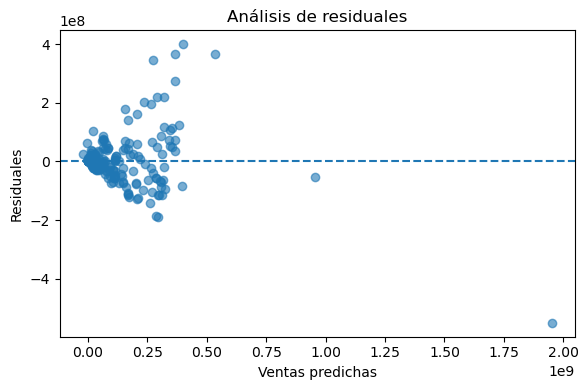

In [45]:
residuals = y_test - y_pred_test

plt.figure(figsize=(6,4))
plt.scatter(y_pred_test, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel('Ventas predichas')
plt.ylabel('Residuales')
plt.title('Análisis de residuales')
plt.tight_layout()
plt.show()

* Los residuales se distribuyen alrededor de cero para la mayoría de las observaciones, lo que indica ausencia de sesgos.
* Se observa mayor dispersión en ventas altas..
* Existen algunos valores atípicos, indicando menor precisión del modelo para empresas grandes.

## 1.5. Gráfica Ventas Reales vs Ventas Predichas

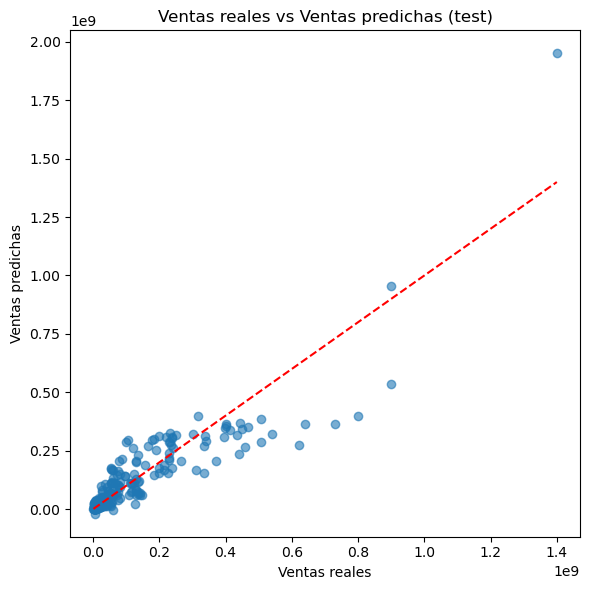

In [46]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('Ventas reales')
plt.ylabel('Ventas predichas')
plt.title('Ventas reales vs Ventas predichas (test)')
plt.tight_layout()
plt.show()

La gráfica muestra que la mayoría de las observaciones se concentran cerca de la línea de 45°, lo que indica una buena capacidad predictiva del modelo, aunque se observan desviaciones mayores para empresas con niveles de ventas elevados.

## 1.6.  Conclusiones Regresión Lineal
El modelo de regresión lineal explica aproximadamente el 78% de la variabilidad en las ventas, lo que indica una capacidad explicativa buena para datos económicos a nivel país.
De acuerdo con los coeficientes estimados, la variable training es la que mayor impacto tiene sobre las ventas, seguida por el nivel de competencia. Esto sugiere que el capital humano y el entorno competitivo son factores clave en el desempeño económico de las empresas.
El modelo es especialmente útil para explicar el comportamiento de ventas promedio, pero menos preciso en los extremos.

# 2. Regresión Logística

## 2.1. Creación de variable binaria

In [49]:
df_model = df_model.copy()

# promedio de ventas
mean_sales = df_model['sales'].mean()

# variable binaria de éxito
df_model['successful'] = (df_model['sales'] > mean_sales).astype(int)

df_model['successful'].value_counts()

successful
0    922
1    398
Name: count, dtype: int64

In [50]:
mean_sales

np.float64(93153808.87727273)

In [51]:
df_model.head()

,sales,employees,training,financing_obtained,exporter,competition_level,successful
0,30700000,53,0.0,1,0,0,0
1,29000000,22,0.0,1,0,0,0
2,43000000,107,0.0,1,0,0,0
3,135000000,270,0.0,1,0,0,1
4,6000000,15,0.0,1,0,0,0


## 2.2. Modelo

In [55]:
# Definir variables dependientes y dependientes
X = df_model[['employees', 'training', 'financing_obtained', 'exporter', 'competition_level']]
y = df_model['successful']

#Separar datos de entrenamiento y prueba¶
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.2, random_state=2)

#Entrenar modelo
model = LogisticRegression(max_iter=1000)
model.fit(trainX, trainy)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 2.3. Evaluar la precisión del modelo

In [56]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(testX)
accuracy = accuracy_score(testy, y_pred)
accuracy

0.9053030303030303

In [57]:
testy.value_counts(normalize=True)

successful
0    0.704545
1    0.295455
Name: proportion, dtype: float64

Aunque la variable dependiente presenta un desbalance moderado, el modelo de regresión logística alcanza una precisión del 90.5%, superando ampliamente el desempeño de un clasificador base.

## 2.4. Matriz de confusión

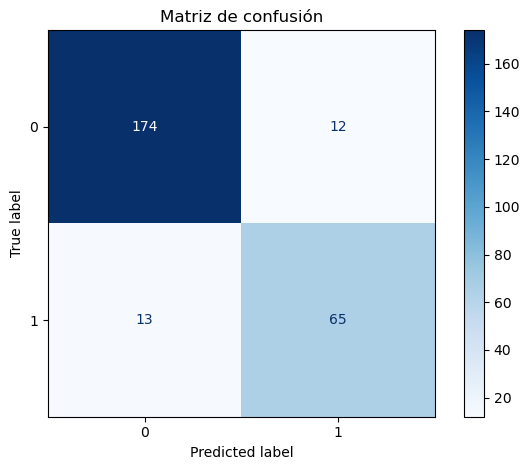

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(testy, model.predict(testX))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.tight_layout()
plt.show()

True negatives = 174  
False positives = 12  
False negatives = 13  
True positives = 65  
La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de las observaciones, con un número reducido de falsos positivos y falsos negativos, lo que refuerza el buen desempeño observado en la métrica de precisión.

## 2.5. ROC y AUC

In [62]:
#ROC
y_prob = model.predict_proba(testX)[:, 1]
roc_auc = roc_auc_score(testy, y_prob)
roc_auc

0.9787358698649021

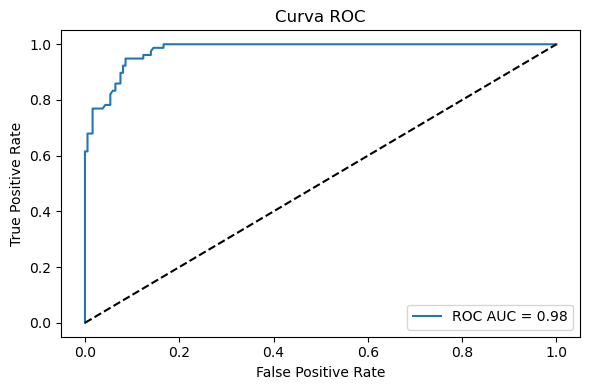

In [64]:
fpr, tpr, _ = roc_curve(testy, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()

La curva ROC obtenida presenta un AUC de 0.98, lo que indica un desempeño sobresaliente del modelo de regresión logística. El modelo muestra una alta capacidad para discriminar entre empresas exitosas y no exitosas.

## 2.6. Conclusiones Regresión Logística

Los resultados del modelo indican que el éxito empresarial puede ser predicho de manera efectiva a partir de características internas y del entorno de la empresa. Variables como la capacitación del personal, el tamaño de la empresa, el nivel de competencia y la participación en mercados internacionales son factores clave que incrementan la probabilidad de éxito, mientras que la falta de financiamiento y la ausencia de exportaciones se asocian con un mayor riesgo de fracaso.

# 3. Bayes

## 3.1. Modelo

In [70]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

#variables
X = df_model[['training', 'financing_obtained', 'competition_level', 'exporter']]
y = df_model['successful']

#División para entrenamiento
trainX, testX, trainy, testy = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Entrenamiento del modelo bayesiano
nb_model = CategoricalNB()
nb_model.fit(trainX, trainy)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


## 3.2. Evaluación del modelo

In [71]:
y_pred_nb = nb_model.predict(testX)
accuracy_nb = accuracy_score(testy, y_pred_nb)

print(f"Accuracy CategoricalNB: {accuracy_nb:.4f}")

Accuracy CategoricalNB: 0.7538


El modelo de regresión logística mostró una mayor exactitud.

## 3.3. Gráfica

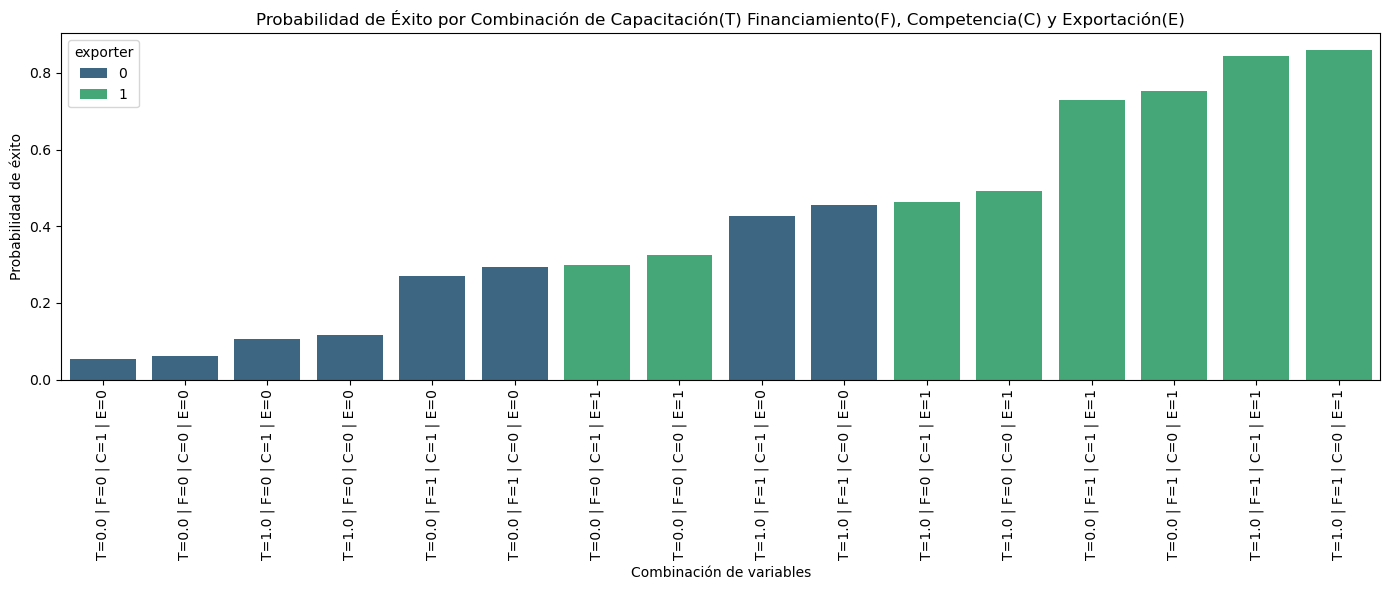

In [85]:
import seaborn as sns

combinations = pd.DataFrame([
    (t, f, c, e)
    for t in X['training'].unique()
    for f in X['financing_obtained'].unique()
    for c in X['competition_level'].unique()
    for e in X['exporter'].unique()
], columns=['training', 'financing_obtained', 'competition_level', 'exporter'])

combinations['prob_success'] = nb_model.predict_proba(combinations)[:, 1]

combinations['scenario'] = (
    'T=' + combinations['training'].astype(str) +
    ' | F=' + combinations['financing_obtained'].astype(str) +
    ' | C=' + combinations['competition_level'].astype(str) +
    ' | E=' + combinations['exporter'].astype(str)
)

combinations_sorted = combinations.sort_values('prob_success')

plt.figure(figsize=(14,6))
sns.barplot(
    data=combinations_sorted,
    x='scenario',
    y='prob_success',
    hue='exporter',
    palette='viridis'
)

plt.xticks(rotation=90)  # Girar etiquetas para que se lean
plt.ylabel('Probabilidad de éxito')
plt.xlabel('Combinación de variables')
plt.title('Probabilidad de Éxito por Combinación de Capacitación(T) Financiamiento(F), Competencia(C) y Exportación(E)')
plt.tight_layout()
plt.show()

El éxito empresarial parece depender de la combinación de recursos financieros, capacitación de la empresa y acceso a mercados externos. Ninguna variable sola garantiza un alto éxito, pero juntas potencian significativamente la probabilidad de éxito.

# 4. Conclusión Final
Para un responsable de políticas públicas, el modelo bayesiano es más útil, ya que permite simular escenarios y priorizar acciones, por ejemplo: aumentar programas de capacitación o facilitar acceso a financiamiento para empresas con baja probabilidad de éxito. 
Se recomienda usar el enfoque bayesiano como herramienta de planificación de políticas y toma de decisiones basadas en evidencia.